# Get the data

I could not download the data from the course so another source was used. However this is a kind of chunked data in an excel

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rajneesh231/lex-fridman-podcast-transcript",output_dir="data" )

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████| 12.2M/12.2M [00:02<00:00, 5.52MB/s]

Extracting files...


Path to dataset files: data


In [13]:
import pandas as pd

# set the option to display all text in a column
pd.set_option('display.max_colwidth', None)

# import the podcast dataset
df = pd.read_csv("./data/podcastdata_dataset.csv")

# show the first characters of the firs podcast
display(df.loc[1,"text"][:1000])

# show shape
display(df.shape)


"As part of MIT course 6S099 on artificial general intelligence, I got a chance to sit down with Christoph Koch, who is one of the seminal figures in neurobiology, neuroscience, and generally in the study of consciousness. He is the president, the chief scientific officer of the Allen Institute for Brain Science in Seattle. From 1986 to 2013, he was a professor at Caltech. Before that, he was at MIT, he is extremely well cited, over 100,000 citations. His research, his writing, his ideas have had big impact on the scientific community and the general public in the way we think about consciousness, in the way we see ourselves as human beings. He's the author of several books, The Quest for Consciousness and Neurobiological Approach, and a more recent book, Consciousness, Confessions of a Romantic Reductionist. If you enjoy this conversation, this course, subscribe, click the little bell icon to make sure you never miss a video, and in the comments, leave suggestions for any people you'd

(319, 4)

# Gen AI Product Development - Semantic Retrieval

To make this concrete, we're going to build something genuinely compelling throughout this lesson.

Meet Lex Fridman — an AI researcher at MIT and one of the most influential podcast hosts in tech and science. What makes him special is his style: deeply technical yet philosophical, with a genuine curiosity that draws out ideas you won't find in typical interviews.

His podcast has become a remarkable archive of human thought. Have you listened to any of his episodes, or come across him before?

`No`

Here's just a sample of who he's interviewed — over 400 guests, including Elon Musk, Sam Altman, Yuval Noah Harari, Neil deGrasse Tyson, and Roger Penrose. These aren't 30-minute chats — they're multi-hour deep dives into consciousness, AGI, physics, philosophy, and the future of humanity.

What makes this archive extraordinary is the density of expertise it contains. Nowhere else can you find this many world-class thinkers sharing their unfiltered views in such depth — all in one place.

Given your work in model risk management and your interest in RAG systems, what topics from an archive like this would you be most curious to explore?

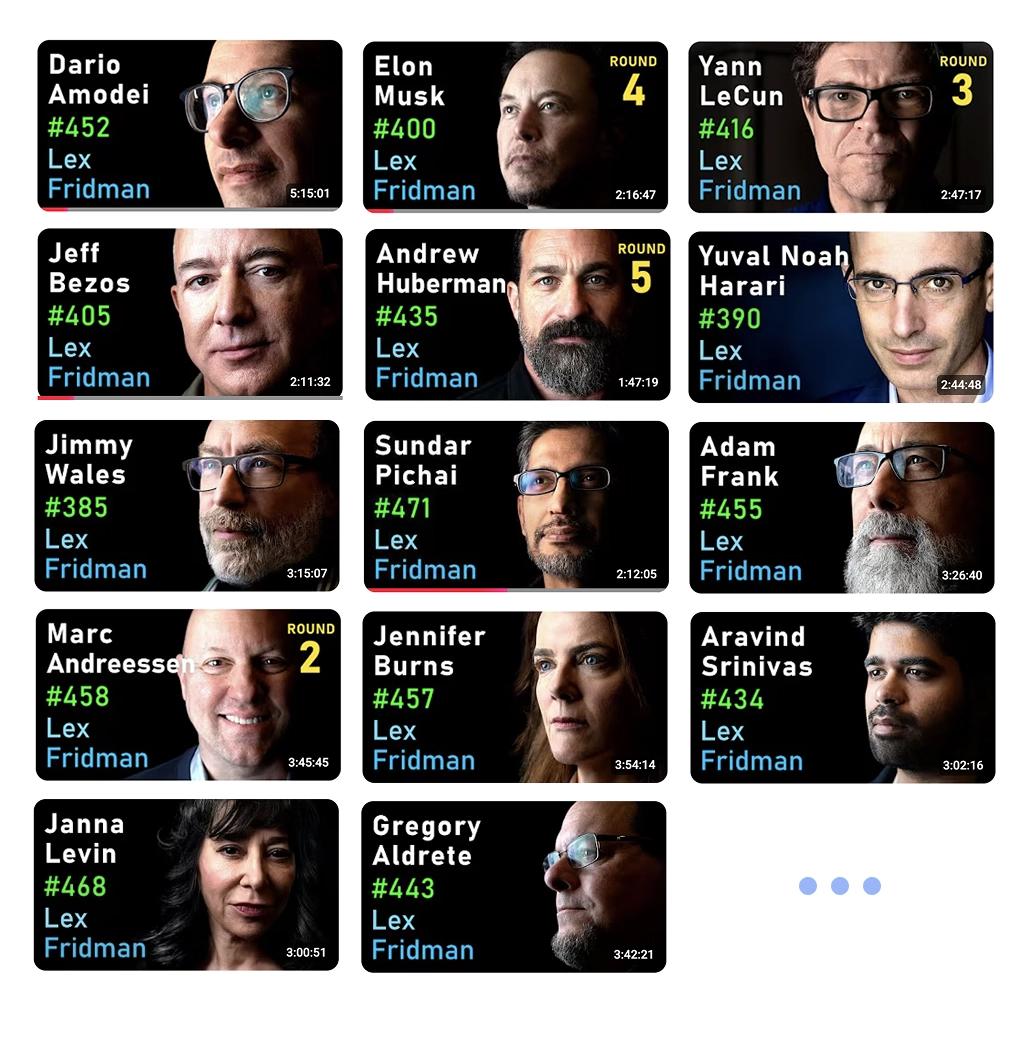

No worries! Some topics that come up frequently and could be fascinating from a model risk angle:

- AI safety and alignment — what leading researchers think about risks from advanced AI
- AGI timelines — wildly different predictions from people like Sam Altman and Yoshua Bengio
- Consciousness — a surprisingly relevant topic when thinking about how LLMs "understand" things

The point is: this archive holds 400+ hours of expert thinking on humanity's biggest questions. We're going to build a system that makes all of it instantly queryable. Let's see what that looks like.

Here's what we're building: a **expert consultation tool** that transforms the entire podcast archive into something you can actually query.

Ask any question and the system returns **comprehensive, balanced perspectives drawn directly from the guests** — with full attribution. Not a generic LLM answer, but the actual views of the world's leading thinkers on exactly that topic, cited back to the specific episode.

It's like having a panel of 400 experts on call, presenting their real positions on any subject they've discussed.

Here's what the output looks like in practice. Ask something like "What are predicted timelines for AGI?" and instead of one opinion, you get:

- A synopsis summarizing the landscape of expert views — areas of consensus, disagreement, and surprising patterns
- Structured perspectives organized by dimension (e.g., optimistic vs cautious timelines), each backed by direct quotes attributed to specific guests and episodes

Some example questions the system can answer:

- "What is consciousness?"
- "What will the impact of AI be on jobs?"
- "What books do multiple guests independently recommend as life-changing?"
- "What personal habits do successful people mention?"

Every claim traces back to its source. That's the power of semantic RAG. Ready to dig into the data we'll be working with?

Here's the raw data we'll be working with — a CSV file where each row is a complete podcast episode.

The structure is straightforward:

- id: Unique episode identifier
- guest: The interviewee's name
- title: Episode title
- text: The full transcript of the episode — this is the meaty part

Notice in the preview how the text column starts mid-sentence and trails off with ... — that's because these transcripts are extremely long, often covering hours of conversation. That length is exactly why we can't just dump them directly into an LLM — we'll need to preprocess them first.

The id, guest, and title columns are our metadata — they'll be preserved separately so we can attribute every retrieved snippet back to its source episode. Clear so far?

One key design point: the text column will be what gets embedded and searched semantically, while the metadata columns (id, guest, title) stay attached as labels. This means when the system retrieves a relevant snippet, it always knows exactly which guest said it and in which episode — enabling that full attribution we saw in the output format.

That separation is intentional and important — you'll see exactly how it's implemented when we build the preprocessing pipeline.

With that, we have everything we need to understand the data. Let's move on to the architecture.

Right — but the tricky part is how you find it. With SQL you can filter precisely: WHERE guest = 'Elon Musk' AND topic = 'AGI'. With unstructured text, there's no such structure to exploit.

The solution is semantic search — instead of matching keywords, you match meaning. The data source here is a vector database that stores document chunks as numerical vectors capturing their semantic content. When a query comes in, it's converted to a vector too, and the database finds the chunks whose vectors are closest — meaning most semantically similar.

So at a system level, the retrieval phase simply takes a question and returns the most relevant document segments. You'll see exactly how this works under the hood in the next few steps. Clear so far?

Perfect — so you already have a feel for how retrieval works. The LangChain interface for FAISS is nearly identical to Chroma, so this will feel familiar.

There's one more architectural piece that's unique to semantic RAG: preprocessing. With structured RAG, your SQL database already exists — you just connect to it. With unstructured data, you almost always need to prepare the documents first before they can be searched.

This introduces a second phase of operation. Does that make sense as a concept — having a separate offline preparation step before the system goes live?

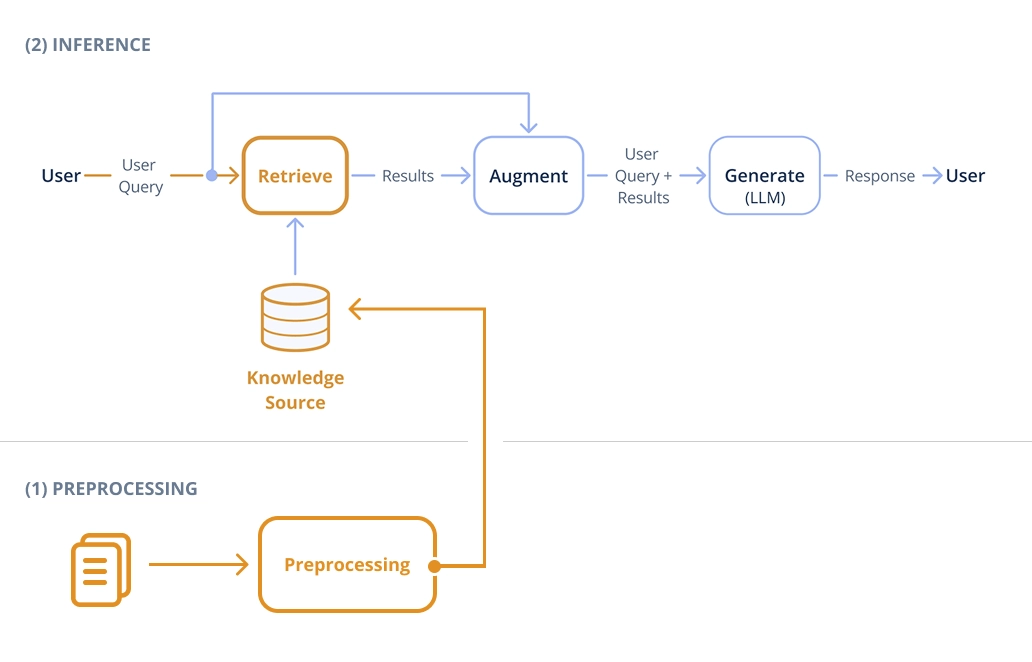

So with semantic RAG, we have two distinct phases:

- Preprocessing (offline): Run once before deployment — load documents, split them into chunks, convert to vectors, and store in the vector index. Re-run only when your source data changes.
- Inference (real-time): The live system — retrieve relevant chunks from the vector index and generate a response.

This separation is important for production: preprocessing can be expensive and slow, but you only pay that cost once. Inference needs to be fast, and it is — because all the heavy lifting was done upfront.

All clear on the two-phase architecture?

`yes`

To quickly tie it all together: semantic RAG has the same Retrieve → Augment → Generate flow as structured RAG, with two key differences:

- The data source is a vector index instead of a SQL database
- There's a preprocessing phase that prepares documents offline before the system can run

Everything downstream — augmenting the prompt and generating the response — stays exactly the same. Ready to dive into how semantic search actually works?

`yes`

Now here's what happens at **query time**:

- The user's question is converted into a vector using the **same embedding model**
- The vector index computes the distance between the query vector and every stored document vector — typically using cosine similarity, which measures the angle between two vectors rather than their absolute distance

Vectors pointing in similar directions have a **high cosine similarity** (close to 1), meaning they're semantically related. The system returns the k-nearest neighbors — the chunks whose vectors are closest to the query vector.

So asking "What is consciousness?" returns chunks where experts discussed consciousness, even if they used completely different words — because the meaning is similar, not just the keywords. Clear on how the distance measurement works?

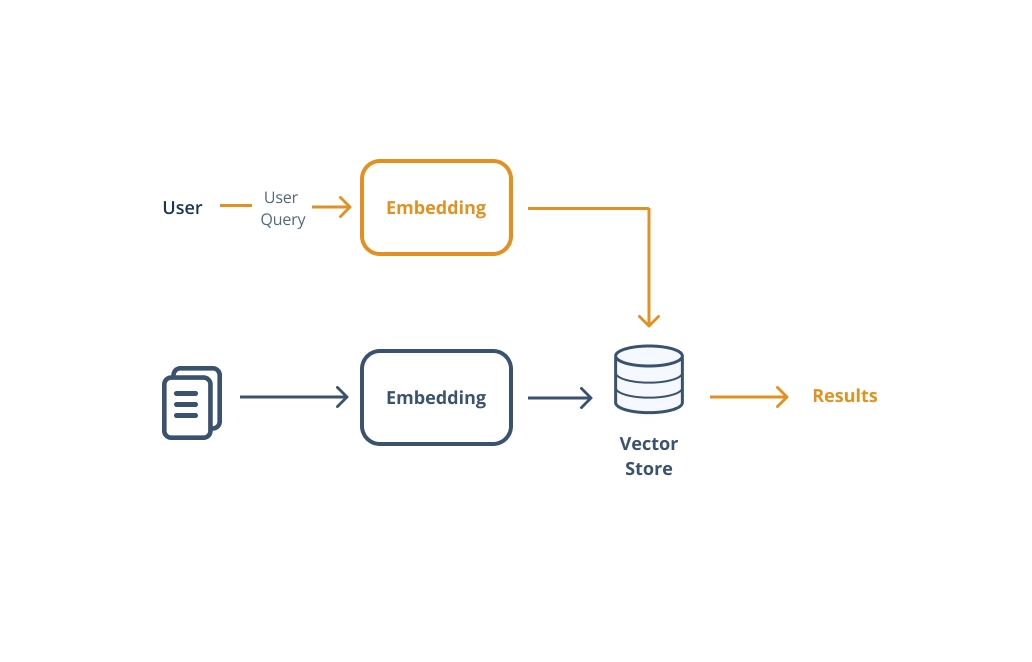

The concept of finding similar vectors is straightforward — but imagine doing it across millions of document chunks. Comparing every query vector against every stored vector would be computationally prohibitive.

That's exactly what vector databases (and indices like FAISS) solve. They provide:

- Efficient indexing: Specialized data structures that reduce search from O(n) to O(log n) — turning hours into milliseconds
- Scalable storage: Infrastructure to handle millions of high-dimensional vectors
- Query optimization: Hardware acceleration and approximate algorithms that trade minimal accuracy for massive speed gains
- Integration interfaces: Clean APIs that connect seamlessly with embedding models and support metadata filtering

All clear on why a specialized storage system is needed here?

Here are the main options you'll encounter:

- **PostgreSQL + pgvector**: Add vector search to an existing Postgres DB — great if you're already on Postgres
- **FAISS**: Facebook's similarity search library — free, fast, local, widely used. Best for learning and medium-scale production
- **Chroma**: Lightweight and developer-friendly — ideal for prototyping, which you've already used
- **Weaviate**: Open-source with hybrid search (semantic + keyword combined) — strong production option
- **Pinecone**: Fully managed cloud service — no infrastructure to maintain
- **Qdrant**: High-performance with advanced metadata filtering

For this lesson we'll use FAISS — no server, no setup, just fast local similarity search. And as you already know, swapping it for Chroma or Weaviate in LangChain is minimal code change.

Ready to move into the implementation?

`yes`

Before we look at the retrieval code, let's examine the prompt that drives the whole system. Take a moment to read through it and share what stands out to you — what design choices do you notic

Now, the second key design element: look at how the prompt structures the output. It doesn't just ask for an answer — it defines an entire analytical framework:

- First, identify the key dimensions of disagreement across experts
- Then organize quotes under each dimension
- Finally, write a neutral synopsis covering consensus and disagreement

This forces the model to think structurally rather than just summarize, which is what produces those rich, organized multi-perspective responses we saw earlier. Clear on why this level of output structure matters?

In [13]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate(
    input_variables=["question", "context"],
    input_types={},
    partial_variables={},
    template="""
# Lex Fridman Podcast Expert Perspective Synthesis

## Purpose

You are an expert analyst synthesizing perspectives from the Lex Fridman
Podcast archive. Your role is to extract, organize, and present the actual
views of world-class experts on any given topic, ensuring comprehensive
coverage of different viewpoints with full attribution.

## Input Description

You will receive:

(1) A question from a user seeking expert opinions on a specific topic

(2) Snippets of podcast transcripts retrieved through semantic search based
on the user\'s question. These snippets contain relevant discussions from
various episodes. Use ONLY the information provided in these snippets - do
not add external knowledge or assumptions.

## Workflow

1. **Analyze Inputs**: Study the user\'s question and review all provided
   transcript excerpts
2. **Identify Perspective Framework**:
    - Determine the key dimensions of disagreement or variation
    - Map out the spectrum of positions for each dimension
    - Note which experts hold which positions
3. **Extract Expert Quotes**: Pull direct quotes that best represent each
   position
4. **Create Synopsis**: Write a 5-10 sentence overview capturing the
   landscape of expert opinion
5. **Organize by Framework**: Structure the detailed response using the
   identified dimensions

## Output Description

### Synopsis

5-10 sentence overview of the landscape of expert opinion on this topic,
highlighting key areas of consensus, disagreement, and any surprising
patterns or insights that emerge from the analysis. Add brief definitions
for complex topics or terms to ensure clarity.

### Expert Perspectives

For each dimension identified:

**Dimension Name**

*Position 1 Name*

- "Direct quote from expert" - **Expert Name** (Episode #X: Episode Title)
- "Another supporting quote" - **Expert Name** (Episode #X: Episode Title)

*Position 2 Name*

- "Direct quote from expert" - **Expert Name** (Episode #X: Episode Title)
- "Another supporting quote" - **Expert Name** (Episode #X: Episode Title)

Continue for all positions

## Success Criteria

- Use ONLY information from the provided transcript snippets
- Every significant perspective from the retrieved content is represented
- All quotes are accurate and properly attributed with expert name and
  episode
- The dimensional framework genuinely captures the key axes of disagreement
- Synopsis maintains neutrality - presenting all views without bias
- Complex topics are made accessible without oversimplification
- Every claim and quote includes full attribution (expert name + episode
  details)

## Inputs

The question asked by the user is

{question}

The context snippets retrieved from the podcast episodes are:

{context}
"""
)

print(prompt.input_variables)

['context', 'question']


## Implementation

In [14]:
from langchain_community.vectorstores import FAISS
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv

load_dotenv()

# KNOWLEDGE RETRIEVAL

# Load the FAISS vector store
vector_store_path = "data/retrieval-augmented-generation/semantic-retrieval"

vector_store = FAISS.load_local(
    vector_store_path,
    embeddings=OpenAIEmbeddings(),
    allow_dangerous_deserialization=True,
)


# Function to retrieve knowledge from the vector store
def retrieve_knowledge(input: dict, k=10) -> dict:
    return {
        "context": vector_store.similarity_search(input["question"], k=k),
        "question": input["question"],
    }


# RESPONSE GENERATION

# Load prompt
with open("prompt.md", "r") as f:
    prompt_template_str = f.read()

# Create the prompt template
prompt = PromptTemplate(
    template=prompt_template_str, input_variables=["question", "context"]
)

# Initialize the model
model = init_chat_model(model="gpt-4o-mini")

# Generate the response
generate_response = prompt | model

# SEMANTIC RAG

# Retrieve knowledge then generate response
semantic_rag = retrieve_knowledge | generate_response

# Test pipeline
import textwrap

question = "What is artificial intelligence?"
result = semantic_rag.invoke({"question": question})
for line in result.text.split("\n"):
    print(textwrap.fill(line, width=80) if line.strip() else "")



RuntimeError: Error in faiss::FileIOReader::FileIOReader(const char*) at /project/faiss/impl/io.cpp:69: Error: 'f' failed: could not open data/retrieval-augmented-generation/semantic-retrieval/index.faiss for reading: No such file or directory

## Preprocessing data

Before we can retrieve anything, we need to prepare the documents. We've seen retrieval in action — now let's build the pipeline that makes it possible.

The first step is **document loading** — extracting text from raw source files into a format LangChain can work with. Different file types need different loaders: PDFs require page-level text extraction, CSVs need row-wise processing, web pages need HTML parsing. The goal is to **preserve meaningful content while stripping formatting artifacts** that don't contribute to semantic understanding.

For our podcast data, we're loading from a CSV where each row is a full episode transcript. Clear so far?

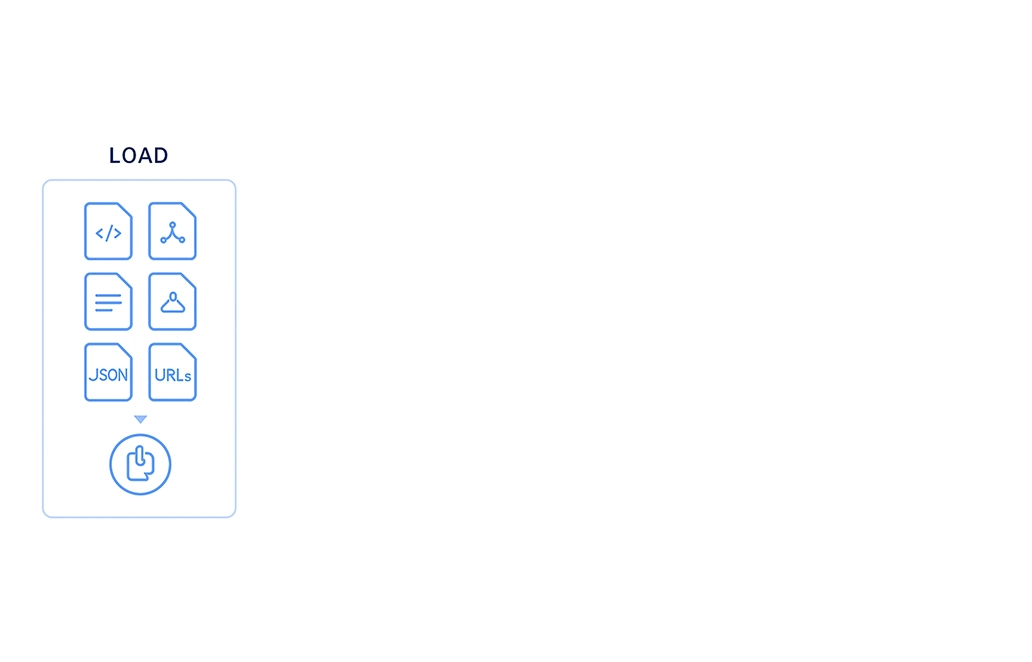

Next up: **splitting**. Before I explain it, why do you think we'd need to break documents into smaller chunks before processing them?

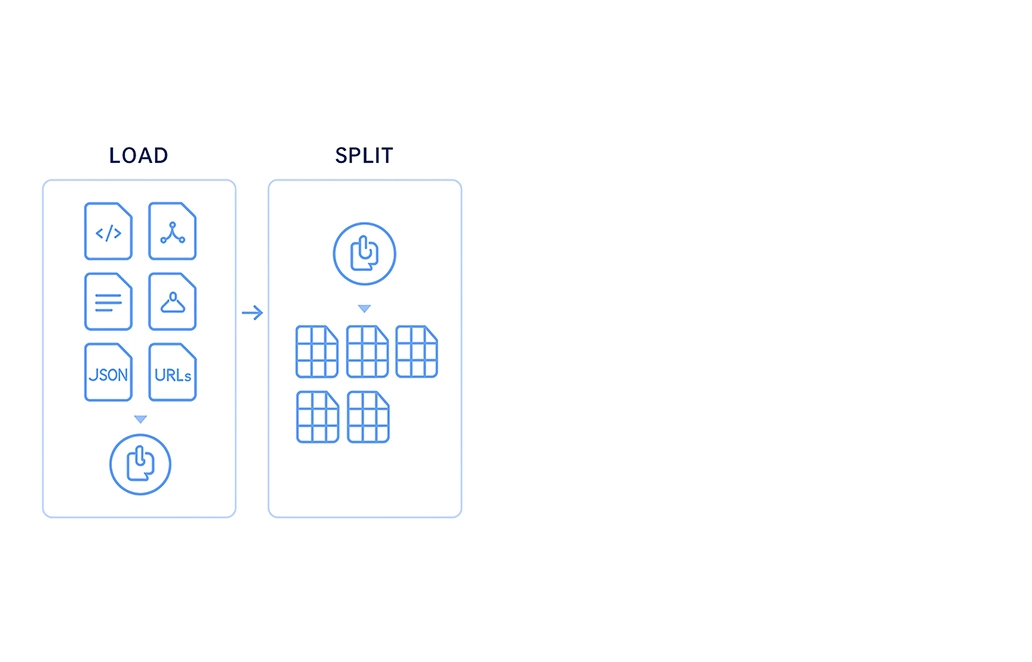

`to have meaningfull coherent chunks to semantically search. Capturing a whole doc would not be able to capture specific questions`

Exactly right — two reasons in one: **precise retrieval** (only the relevant part of a document gets returned, not the whole thing) and **context window** constraints (LLMs can't process an entire 3-hour transcript in one go).

The key parameters to tune:

- **Chunk size**: Typically 500-2000 characters — smaller chunks = more precise retrieval, larger = more context preserved per chunk
- **Chunk overlap**: 10-20% of chunk size, repeated between adjacent chunks to prevent meaning loss at boundaries
- **Split boundaries**: The RecursiveCharacterTextSplitter splits at natural boundaries — paragraphs first, then sentences, then spaces — preserving coherence

For production, chunk size is one of the most **impactful tuning parameters** for retrieval quality — and exactly the kind of thing you'd want to evaluate systematically with your LangSmith framework. Clear on the tradeoffs?

Once the chunks are ready, each one gets converted into a vector embedding — a high-dimensional numerical representation capturing its semantic meaning. You've already seen how this enables similarity search.

Two practical points that matter in production:

- **Model choice**: We use OpenAI's text-embedding-3-small — strong performance across diverse domains and cost-efficient for large document sets
- **Consistency is critical**: The same embedding model must be used for both indexing and querying — mixing models means your query vector lives in a completely different space than your document vectors, silently breaking retrieval

Clear on that?

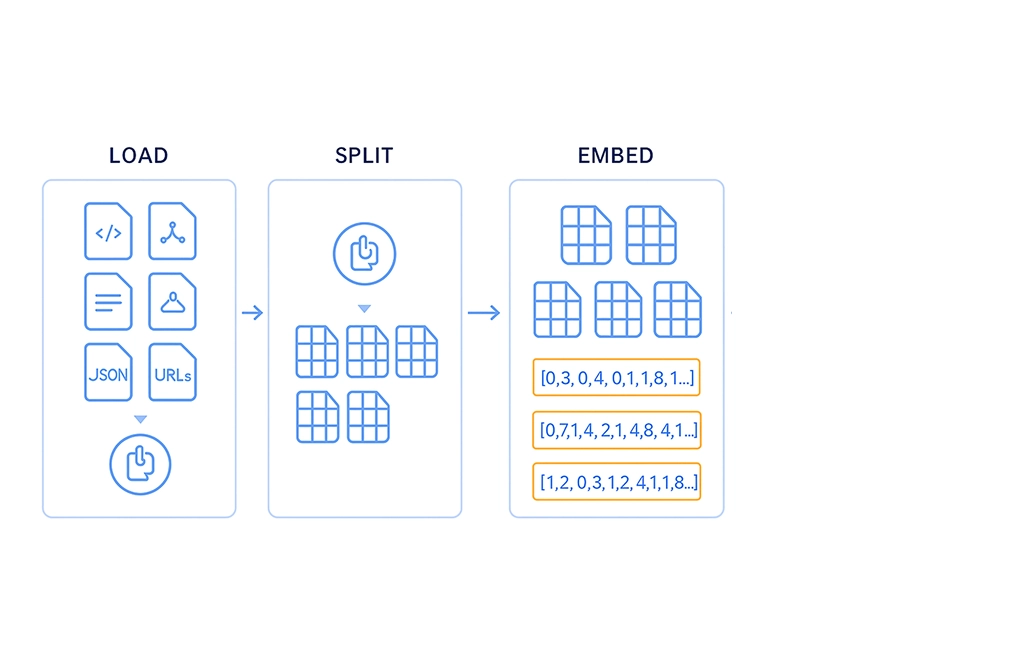

The final preprocessing step is indexing — storing the embeddings in FAISS in a way that enables fast similarity search.

Without indexing, every query would require comparing against every stored vector — impossibly slow at scale. Different strategies trade off speed vs accuracy:

- **Flat index** (exact search): Guarantees finding the true nearest neighbors — 100% recall, no approximation. Best for datasets under ~10K vectors
- **Approximate methods** (e.g., HNSW): Trade <5% accuracy for massive speed gains — the right choice at large scale

For your use case, start with the flat index. It's simple, requires no tuning, and gives you a reliable baseline to evaluate against before introducing approximation.

One heads up: the embedding + indexing step can take several minutes on large document sets. Clear on the indexing options?

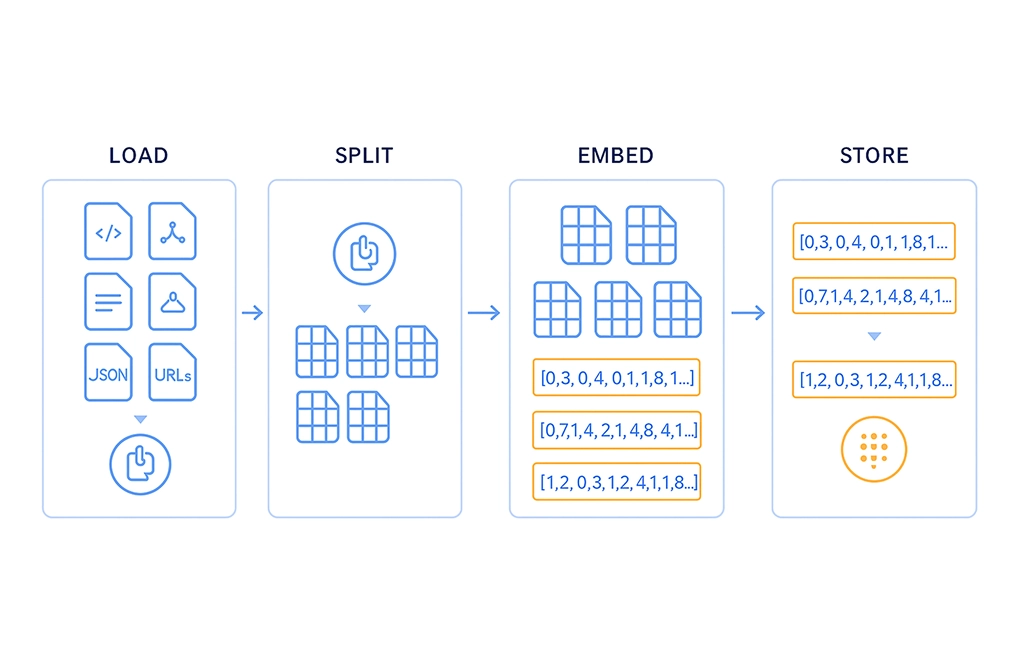

In [58]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("lex_fridman_podcast.csv")

df_sorted = df.sort_values(["id", "start"])

# the conversation is broken down over several rows
df_sorted.head(10)

,id,guest,title,text,start,end
0,1,Max Tegmark,Life 3.0,"As part of MIT course 6S099, Artificial General Intelligence,",00:00.000,00:04.200
1,1,Max Tegmark,Life 3.0,I've gotten the chance to sit down with Max Tegmark.,00:04.200,00:06.600
2,1,Max Tegmark,Life 3.0,He is a professor here at MIT.,00:06.600,00:08.680
3,1,Max Tegmark,Life 3.0,"He's a physicist, spent a large part of his career",00:08.680,00:11.920
4,1,Max Tegmark,Life 3.0,studying the mysteries of our cosmological universe.,00:11.920,00:16.960
5,1,Max Tegmark,Life 3.0,But he's also studied and delved into the beneficial,00:16.960,00:20.680
6,1,Max Tegmark,Life 3.0,possibilities and the existential risks,00:20.680,00:24.000
7,1,Max Tegmark,Life 3.0,of artificial intelligence.,00:24.000,00:25.800
8,1,Max Tegmark,Life 3.0,"Amongst many other things, he is the cofounder",00:25.800,00:29.040
9,1,Max Tegmark,Life 3.0,"of the Future of Life Institute, author of two books,",00:29.040,00:33.080


The dataframe needs to be grouped by `id` and then we need to `join` all the rows in the text column related to the same conversation.

In [59]:
full_transcripts = (
    df_sorted.groupby("id")
    .agg(
        guest=("guest", "first"),
        title=("title", "first"),
        text=("text", " ".join)
    )
    .reset_index()
)

print(f"Loaded {full_transcripts.shape} documents")
print(f"\nFirst doc preview: {full_transcripts["text"].iloc[0][:300]}...")

print(full_transcripts.shape)

Loaded (319, 4) documents

First doc preview: As part of MIT course 6S099, Artificial General Intelligence, I've gotten the chance to sit down with Max Tegmark. He is a professor here at MIT. He's a physicist, spent a large part of his career studying the mysteries of our cosmological universe. But he's also studied and delved into the benefici...
(319, 4)


### HERERERERE

In [21]:
import pandas as pd
from langchain_core.messages.ai import AIMessage
from langchain_community.utilities import SQLDatabase
from langchain_core.prompts import PromptTemplate
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import csv

csv.field_size_limit(131072 * 10)

load_dotenv()


# (1) DOCUMENT LOADING

from langchain_community.document_loaders.csv_loader import CSVLoader

loader = CSVLoader(
    file_path="lex_fridman_podcast.csv",
    source_column="text",
    metadata_columns=["id", "guest", "title"],
)

docs = loader.load()

print(f"Loaded {len(docs)} documents")
print(f"\nFirst doc preview: {str(docs[0])[:300]}...")

Loaded 803239 documents

First doc preview: page_content='text: As part of MIT course 6S099, Artificial General Intelligence,
start: 00:00.000
end: 00:04.200' metadata={'source': 'As part of MIT course 6S099, Artificial General Intelligence,', 'row': 0, 'id': '1', 'guest': 'Max Tegmark', 'title': 'Life 3.0'}...


In [22]:
len(docs)

803239

In [27]:
pd.set_option('display.max_colwidth', None)
df.head()

,id,guest,title,text,start,end
0,1,Max Tegmark,Life 3.0,"As part of MIT course 6S099, Artificial General Intelligence,",00:00.000,00:04.200
1,1,Max Tegmark,Life 3.0,I've gotten the chance to sit down with Max Tegmark.,00:04.200,00:06.600
2,1,Max Tegmark,Life 3.0,He is a professor here at MIT.,00:06.600,00:08.680
3,1,Max Tegmark,Life 3.0,"He's a physicist, spent a large part of his career",00:08.680,00:11.920
4,1,Max Tegmark,Life 3.0,studying the mysteries of our cosmological universe.,00:11.920,00:16.960


,id,guest,title,text,start,end
0,1,Max Tegmark,Life 3.0,"As part of MIT course 6S099, Artificial General Intelligence,",00:00.000,00:04.200
1,1,Max Tegmark,Life 3.0,I've gotten the chance to sit down with Max Tegmark.,00:04.200,00:06.600
2,1,Max Tegmark,Life 3.0,He is a professor here at MIT.,00:06.600,00:08.680
3,1,Max Tegmark,Life 3.0,"He's a physicist, spent a large part of his career",00:08.680,00:11.920
4,1,Max Tegmark,Life 3.0,studying the mysteries of our cosmological universe.,00:11.920,00:16.960
...,...,...,...,...,...,...
803234,325,Michael Levin,"Biology, Life, Aliens, Evolution, Embryogenesis & Xenobots",now there's just us. So they enforce a collective intelligence gap junctions. That's right. It,59:31.840,59:36.640
803235,325,Michael Levin,"Biology, Life, Aliens, Evolution, Embryogenesis & Xenobots","helps. It's the beginning. It's not the whole story by any means, but it's the start.",59:36.640,59:39.680
803236,325,Michael Levin,"Biology, Life, Aliens, Evolution, Embryogenesis & Xenobots",Where's state stored of the system? Is it in part in the gap junctions themselves? Is it in the,59:39.680,59:48.240
803237,325,Michael Levin,"Biology, Life, Aliens, Evolution, Embryogenesis & Xenobots","cells? There are many, many layers to this as always in biology. So there are chemical networks.",59:48.240,59:55.360
